In [2]:
import pandas as pd

df = pd.read_excel("../Data/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [4]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

Duplicate Rows:
0


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
churn_percentage = df["Churn Label"].value_counts(normalize=True) * 100

churn_percentage

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

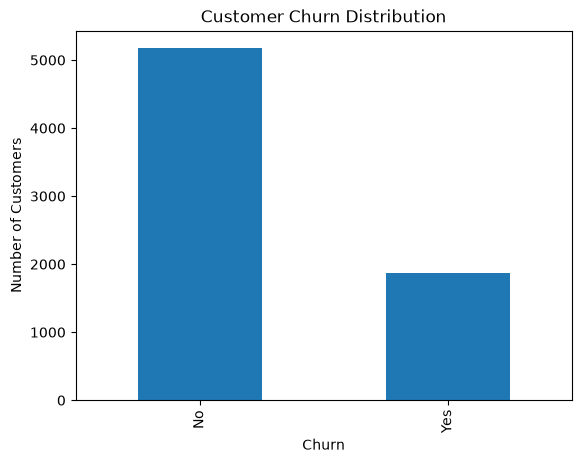

In [10]:
import matplotlib.pyplot as plt

df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


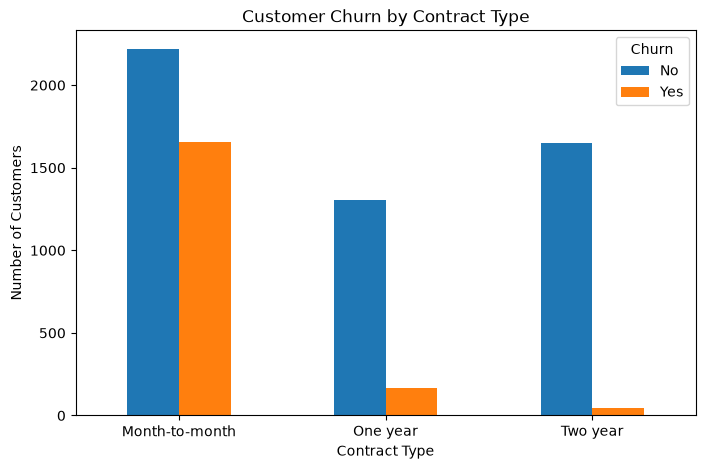

In [12]:
contract_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [13]:
df.groupby("Churn Label")["Tenure Months"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn Label,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


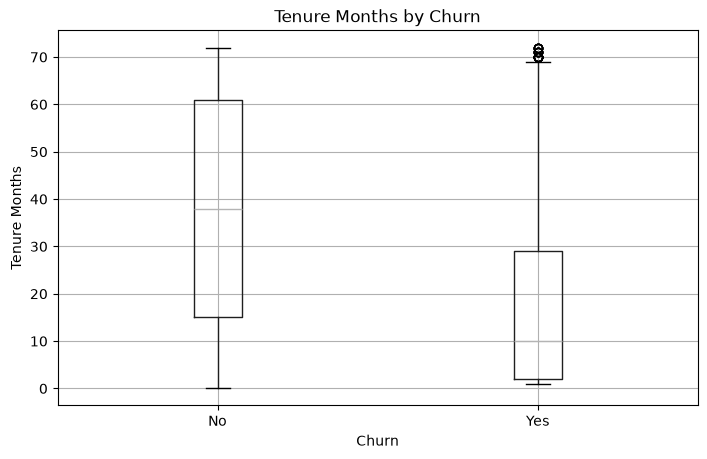

In [14]:
import matplotlib.pyplot as plt

df.boxplot(
    column="Tenure Months",
    by="Churn Label",
    figsize=(8, 5)
)

plt.title("Tenure Months by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")
plt.show()

In [15]:
df.groupby("Churn Label")["Monthly Charges"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn Label,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


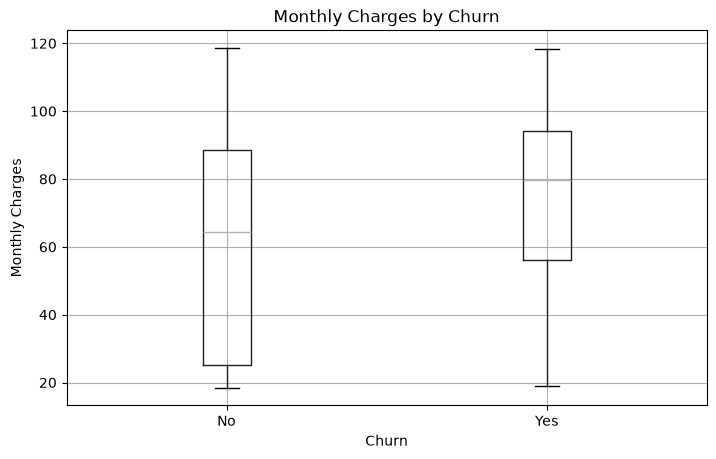

In [16]:
df.boxplot(
    column="Monthly Charges",
    by="Churn Label",
    figsize=(8, 5)
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [17]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"]
)

payment_churn

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


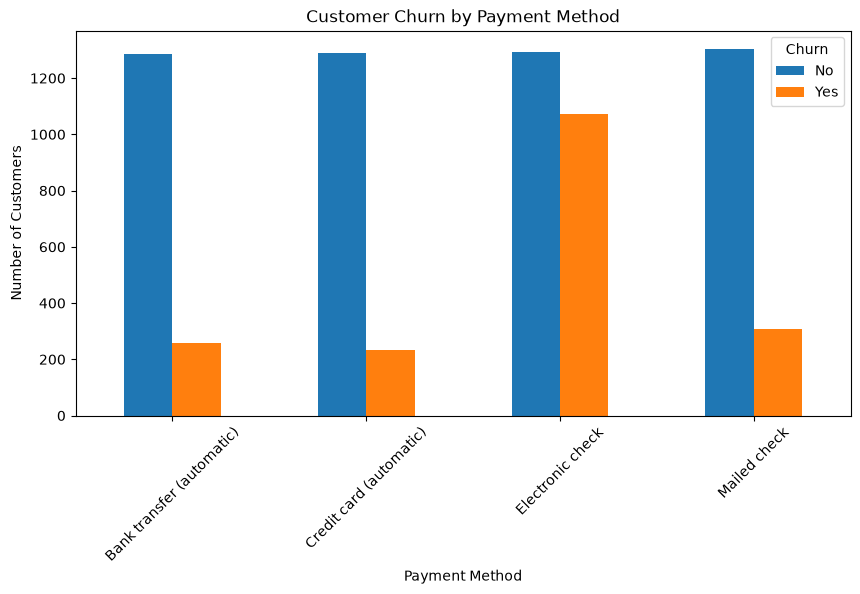

In [18]:
payment_churn.plot(kind="bar", figsize=(10, 5))

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.show()

In [19]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"]
)

internet_churn

Churn Label,No,Yes
Internet Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


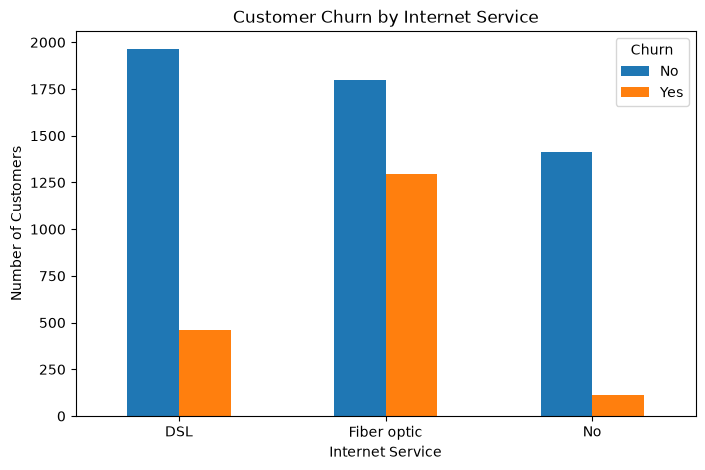

In [20]:
internet_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [21]:
senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"]
)

senior_churn

Churn Label,No,Yes
Senior Citizen,,
No,4508,1393
Yes,666,476


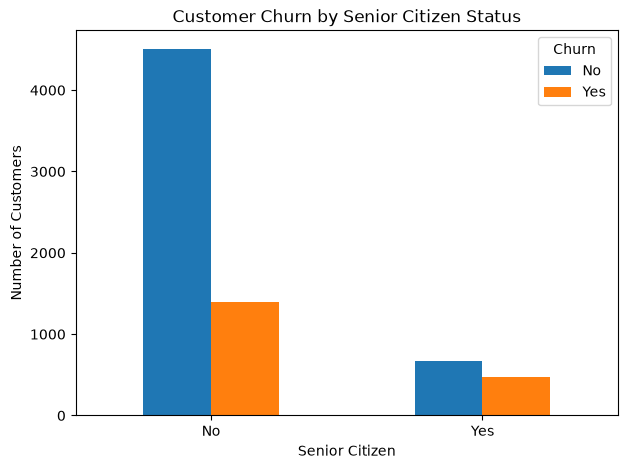

In [22]:
senior_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [23]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn Label"]
)

partner_churn

Churn Label,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


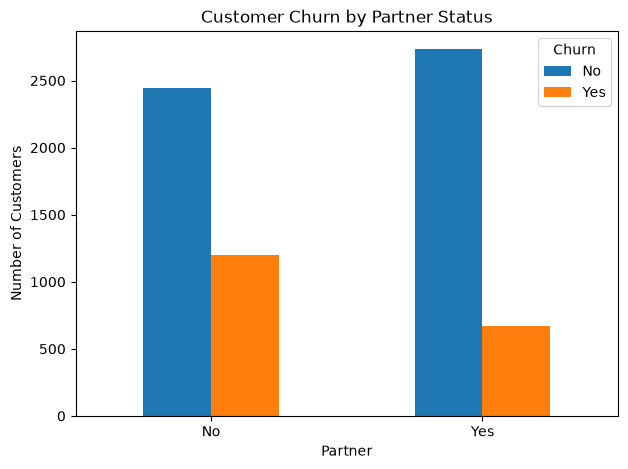

In [24]:
partner_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [25]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn Label"]
)

dependents_churn

Churn Label,No,Yes
Dependents,,
No,3653,1763
Yes,1521,106


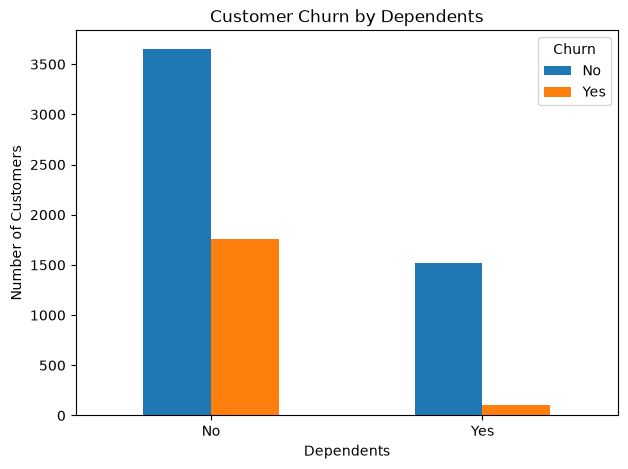

In [26]:
dependents_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [28]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df["Total Charges"].isnull().sum()

np.int64(11)

In [29]:
df.groupby("Churn Label")["Total Charges"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn Label,,,,
No,2555.344141,1683.60,18.80,8672.45
Yes,1531.796094,703.55,18.85,8684.80


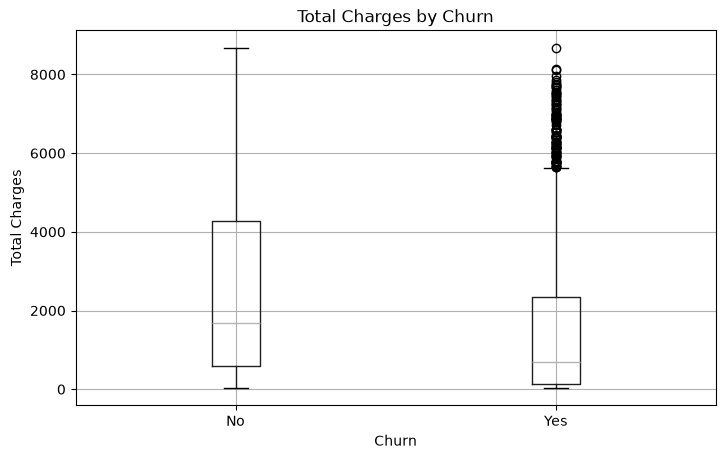

In [30]:
df.boxplot(
    column="Total Charges",
    by="Churn Label",
    figsize=(8, 5)
)

plt.title("Total Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [31]:
churn_reasons = df[df["Churn Label"] == "Yes"]["Churn Reason"].value_counts()

churn_reasons

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

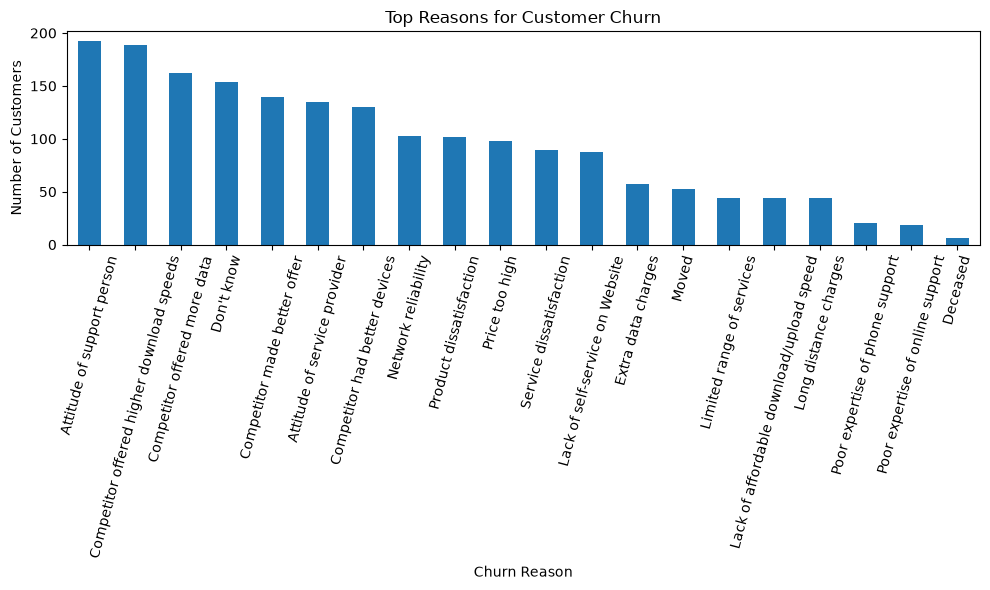

In [32]:
churn_reasons.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Top Reasons for Customer Churn")
plt.xlabel("Churn Reason")
plt.ylabel("Number of Customers")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [33]:
df.groupby("Churn Label")["Churn Score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,50.098183,50.0,5,80
Yes,82.510433,82.0,65,100


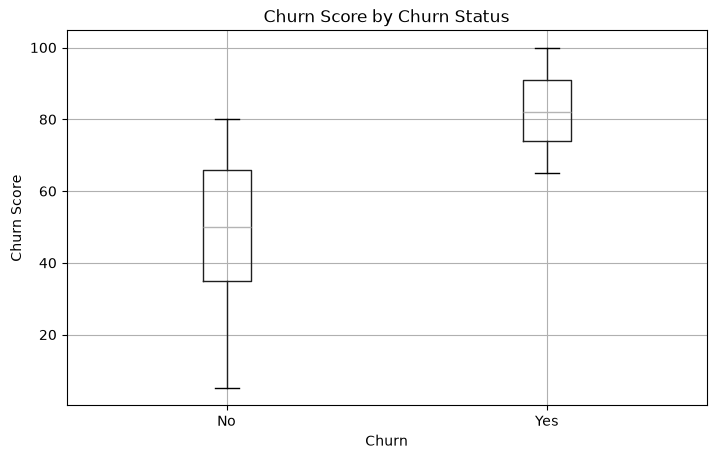

In [34]:
df.boxplot(
    column="Churn Score",
    by="Churn Label",
    figsize=(8, 5)
)

plt.title("Churn Score by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Churn Score")
plt.show()

In [36]:
df["Churn"] = df["Churn Label"].map({
    "Yes": 1,
    "No": 0
})

df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [37]:
features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges"
]

X = df[features]
y = df["Churn"]

X.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30


In [38]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,False,False,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,False,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,False,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,True,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [41]:
X = X.fillna(X.median(numeric_only=True))

X.isnull().sum().sum()

np.int64(0)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


C:\Users\aadia\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy %:", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8062455642299503
Accuracy %: 80.62 %


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.58      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



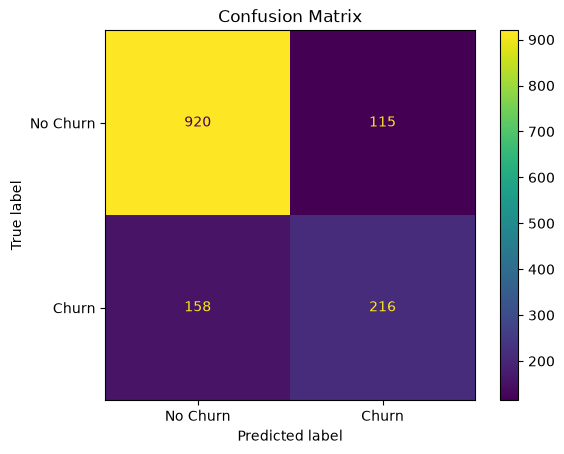

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [48]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Importance
6,Dependents_Yes,-1.606883,1.606883
25,Contract_Two year,-1.306423,1.306423
24,Contract_One year,-0.725387,0.725387
10,Internet Service_Fiber optic,0.694323,0.694323
13,Online Security_Yes,-0.417550,0.417550
7,Phone Service_Yes,-0.401947,0.401947
19,Tech Support_Yes,-0.388945,0.388945
28,Payment Method_Electronic check,0.377193,0.377193
26,Paperless Billing_Yes,0.363443,0.363443
9,Multiple Lines_Yes,0.292042,0.292042


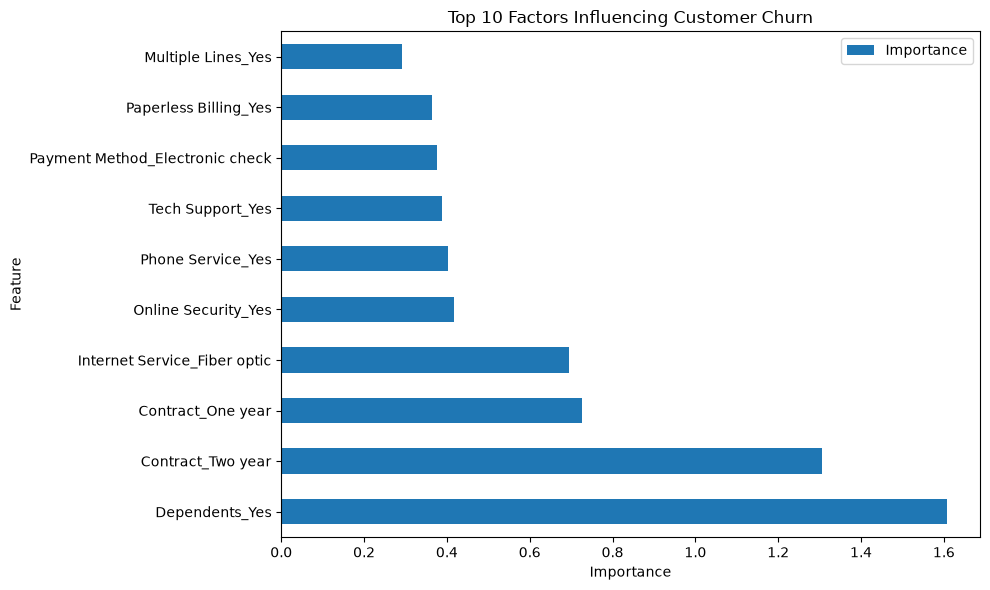

In [49]:
top_features = feature_importance.head(10)

top_features.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Factors Influencing Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Business Insights

- Customers with month-to-month contracts show higher churn compared with customers on longer-term contracts.
- Customers with shorter tenure are more likely to churn.
- Monthly charges show a relationship with customer churn.
- Payment method and internet service type show differences in churn behavior.
- Customer support and security-related services can help identify customers with different churn patterns.
- Machine learning was used to identify important factors associated with customer churn and support retention-focused decision making.